In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load dataset
df = pd.read_excel("titanic_sample_dataset.xlsx")

# 1. Rename unnamed column

In [3]:
df.rename(columns={"Unnamed: 3": "name"}, inplace=True)

2. Remove duplicate rows

In [4]:
df.drop_duplicates(inplace=True)

 3. Handle missing values

In [5]:
df.replace(["?", "**", ""], np.nan, inplace=True)

Fill missing gender with mode

In [6]:
df["gender"].fillna(df["gender"].mode()[0], inplace=True)

/tmp/ipykernel_976/4193680292.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["gender"].fillna(df["gender"].mode()[0], inplace=True)


Convert age to numeric

In [7]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")

Fill missing age with median

In [8]:
df["age"].fillna(df["age"].median(), inplace=True)

/tmp/ipykernel_976/3040546416.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].median(), inplace=True)


 Convert fare to numeric

In [9]:
df["fare"] = pd.to_numeric(df["fare"], errors="coerce")

 Fill missing fare with median

In [ ]:
df["fare"].fillna(df["fare"].median(), inplace=True)

Fill embarked missing values with mode

In [10]:
df["embarked"].fillna(df["embarked"].mode()[0], inplace=True)

/tmp/ipykernel_976/3995229981.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["embarked"].fillna(df["embarked"].mode()[0], inplace=True)


4. Convert data types

In [11]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df["sn"] = df["sn"].astype(int)
df["pclass"] = df["pclass"].astype(int)
df["survived"] = df["survived"].astype(int)
df["family"] = df["family"].astype(int)

/tmp/ipykernel_976/336026892.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"], errors="coerce")


5. Remove extra spaces

In [13]:
df["name"] = df["name"].str.strip()

6. Check cleaned data

In [12]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 0 to 10
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   sn        10 non-null     int64         
 1   pclass    10 non-null     int64         
 2   survived  10 non-null     int64         
 3   name      10 non-null     object        
 4   gender    10 non-null     object        
 5   age       10 non-null     float64       
 6   family    10 non-null     int64         
 7   fare      9 non-null      float64       
 8   embarked  10 non-null     object        
 9   date      10 non-null     datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 880.0+ bytes
None
   sn  pclass  survived                         name  gender   age  family  \
0   1       3         0                  Mr. Anthony    male  42.0       0   
2   2       3         0        Master. Eugene Joseph    male  26.5       2   
3   3       2         0  

 7. Save cleaned dataset

In [14]:
df.to_excel("cleaned_titanic_dataset.xlsx", index=False)

print("Data cleaning completed successfully!")

Data cleaning completed successfully!


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
df = pd.read_excel("cleaned_titanic_dataset.xlsx")

 Basic Dataset Information

In [17]:
print("Shape of dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

print("\nStatistical Summary:")
print(df.describe())

Shape of dataset:
(10, 10)

Column Names:
Index(['sn', 'pclass', 'survived', 'name', 'gender', 'age', 'family', 'fare',
       'embarked', 'date'],
      dtype='object')

First 5 Rows:
   sn  pclass  survived                         name  gender   age  family  \
0   1       3         0                  Mr. Anthony    male  42.0       0   
1   2       3         0        Master. Eugene Joseph    male  26.5       2   
2   3       2         0  Abbott, Mr. Rossmore Edward    male  26.5       2   
3   4       3         1  Abbott, Mr. Rossmore Edward  female  35.0       2   
4   5       3         1  Abelseth, Miss. Karen Marie  female  16.0       0   

    fare embarked       date  
0   7.55        S 1990-01-01  
1  20.25        S 1990-01-02  
2    NaN        S 1990-01-03  
3  20.25        S 1990-01-04  
4   7.65        S 1990-01-05  

Statistical Summary:
             sn     pclass   survived        age     family       fare  \
count  10.00000  10.000000  10.000000  10.000000  10.000000   9.

Survival Count

In [18]:
survival_count = df["survived"].value_counts()

print("\nSurvival Count:")
print(survival_count)


Survival Count:
survived
1    6
0    4
Name: count, dtype: int64


Bar Chart

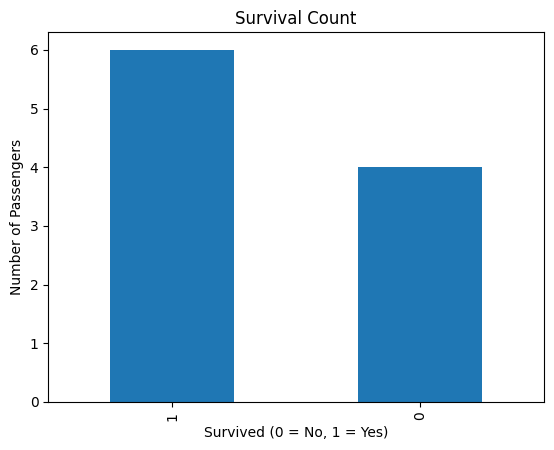

In [19]:
survival_count.plot(kind="bar")

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

Gender Distribution


Gender Distribution:
gender
male      6
female    4
Name: count, dtype: int64


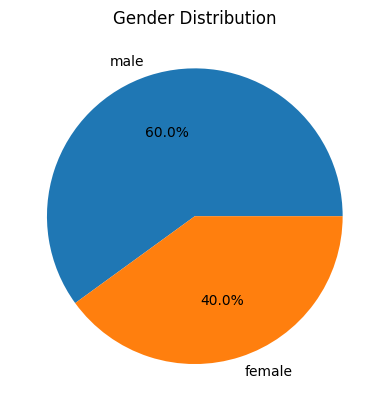

In [20]:
gender_count = df["gender"].value_counts()

print("\nGender Distribution:")
print(gender_count)

gender_count.plot(kind="pie", autopct="%1.1f%%")

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

Age Distribution

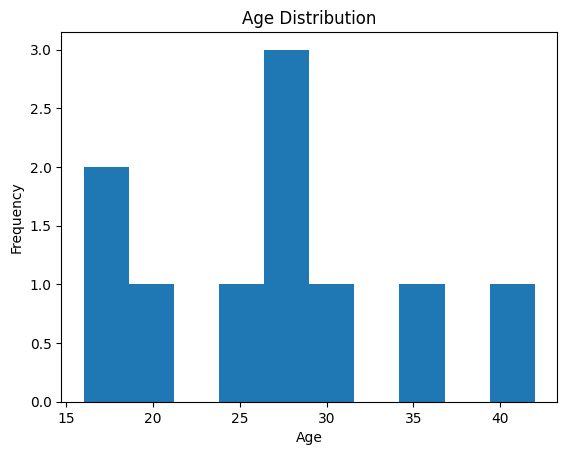

In [21]:
plt.hist(df["age"], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Passenger Class Distribution

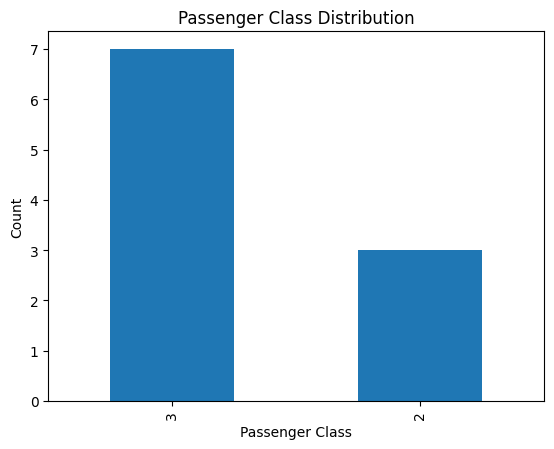

In [22]:
pclass_count = df["pclass"].value_counts()

pclass_count.plot(kind="bar")

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

 Fare Distribution

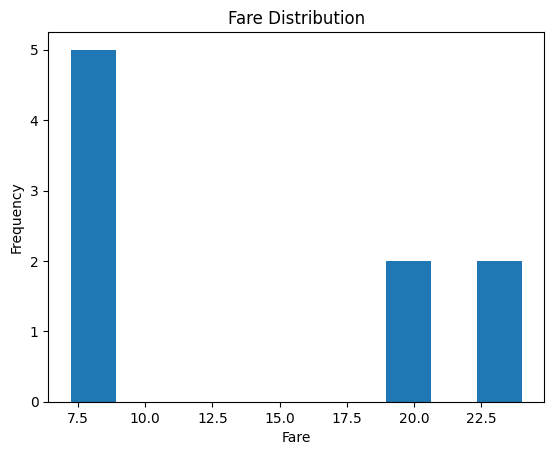

In [23]:
plt.hist(df["fare"], bins=10)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

 Survival by Gender


Survival by Gender:
survived  0  1
gender        
female    0  4
male      4  2


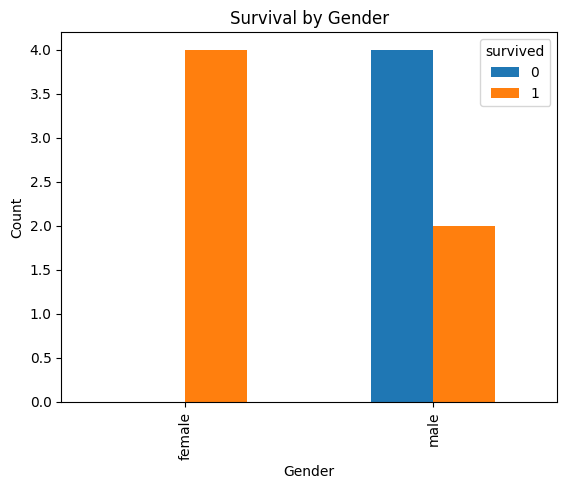

In [24]:
survival_gender = pd.crosstab(df["gender"], df["survived"])

print("\nSurvival by Gender:")
print(survival_gender)

survival_gender.plot(kind="bar")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

Survival by Passenger Class


Survival by Passenger Class:
survived  0  1
pclass        
2         2  1
3         2  5


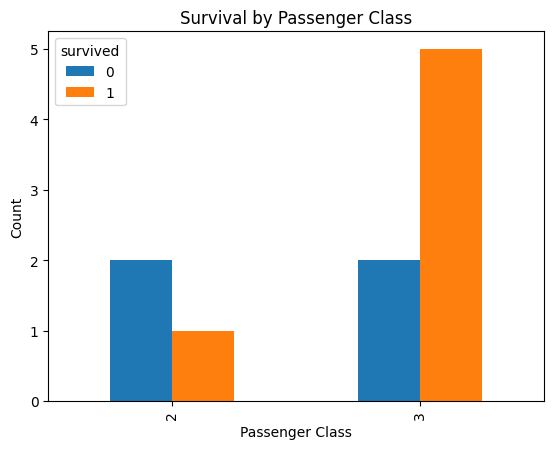

In [25]:
survival_class = pd.crosstab(df["pclass"], df["survived"])

print("\nSurvival by Passenger Class:")
print(survival_class)

survival_class.plot(kind="bar")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

Correlation Matrix

In [26]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation = numeric_df.corr()

print("\nCorrelation Matrix:")
print(correlation)


Correlation Matrix:
                sn    pclass  survived       age    family      fare
sn        1.000000 -0.113961  0.639602 -0.608301 -0.439298 -0.073782
pclass   -0.113961  1.000000  0.356348 -0.129046 -0.400501 -0.725491
survived  0.639602  0.356348  1.000000 -0.499307 -0.421464 -0.309872
age      -0.608301 -0.129046 -0.499307  1.000000  0.314503  0.340879
family   -0.439298 -0.400501 -0.421464  0.314503  1.000000  0.829593
fare     -0.073782 -0.725491 -0.309872  0.340879  0.829593  1.000000


Heatmap using matplotlib

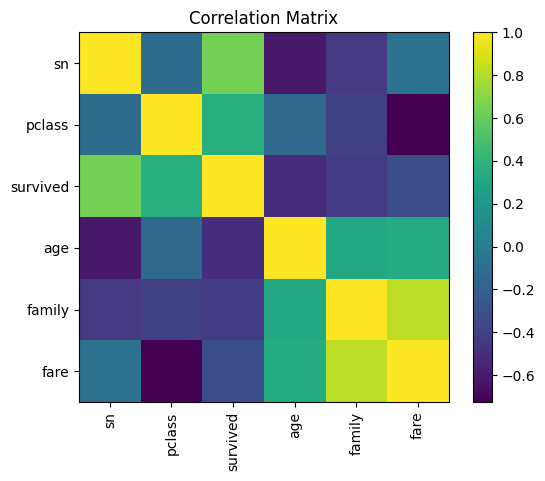

In [27]:
plt.imshow(correlation)

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")
plt.show()